# Notebook Outline
preparing the data to train the models
- [Packages](#1)
- [EDA](#2)
    - [Data loading](#2.1)
    - [Data exploration](#2.2)
    - [Data visualization](#2.3)
- [Cleaning](#3)
    - [Remove nulls and unused columns](#3.1)
    - [Feature engineering](#3.2)
    - [Encoding the categorical columns](#3.3)
    - [Data spliting](#3.4)
    - [Data normalization (z-score)](#3.5)
- [Dataframes Saving](#4)




<a name="1"></a>
## Packages 

In [1]:
#1.importing the libraries that will be used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

<a name="2"></a>
## EDA

<a name="2.1"></a>
### Data loading 

In [2]:
#2.loading the datasets to the dataframes 
df_train = pd.read_csv("data/Train.csv")
df_test = pd.read_csv("data/Test.csv")

In [3]:
df_train.head(2)

,age,work-class,work-fnl,education,education-num,marital-status,position,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K


In [4]:
df_test.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Self-emp-not-inc,21472,Some-college,10,Never-married,Other-service,Not-in-family,White,Female,0,0,22,United-States,<=50K
1,32,Private,90969,Assoc-voc,11,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,45,United-States,>50K


In [5]:
#3.combine the two dataframes
df_test.rename(columns={'workclass' : 'work-class', 'fnlwgt' : 'work-fnl', 'occupation' : 'position'} , inplace=True)
df = pd.concat([df_train, df_test], keys=['train', 'test'])

In [6]:
df.head()

age         work-class  work-fnl   education  education-num  \
train 0   39          State-gov     77516   Bachelors             13   
      1   50   Self-emp-not-inc     83311   Bachelors             13   
      2   38            Private    215646     HS-grad              9   
      3   53            Private    234721        11th              7   
      4   28            Private    338409   Bachelors             13   

              marital-status            position    relationship    race  \
train 0        Never-married        Adm-clerical   Not-in-family   White   
      1   Married-civ-spouse     Exec-managerial         Husband   White   
      2             Divorced   Handlers-cleaners   Not-in-family   White   
      3   Married-civ-spouse   Handlers-cleaners         Husband   Black   
      4   Married-civ-spouse      Prof-specialty            Wife   Black   

             sex  capital-gain  capital-loss  hours-per-week  native-country  \
train 0     Male          2174             0              40   United-States   
      1     Male             0             0              13   United-States   
      2     Male             0             0              40   United-States   
      3     Male             0             0              40   United-States   
      4   Female             0             0              40            Cuba   

         salary  
train 0   <=50K  
      1   <=50K  
      2   <=50K  
      3   <=50K  
      4   <=50K

<a name="2.2"></a>
### Data exploration

In [7]:
#4.change the ? to null value with Regex
df.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 32561 entries, ('train', np.int64(0)) to ('test', np.int64(9768))
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   work-class      30725 non-null  str  
 2   work-fnl        32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   position        30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  salary          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 4.0+ MB


In [8]:
df['salary'] = (df['salary'].str.contains('>50K')).astype(int)
categorical_columns = ['work-class', 'education', 'marital-status', 'position', 'relationship', 'race', 'sex']
numeric_columns = ['age', 'work-fnl' ,'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'salary']

In [9]:
numeric_df = df[numeric_columns]
numeric_df.describe()

,age,work-fnl,education-num,capital-gain,capital-loss,hours-per-week,salary
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,0.240810
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [10]:
#5.chick if the data is balanced or not 
print('for all the df: ')
print(f'Number of people that take >50K = {sum(df['salary'])} with % = {np.mean(df['salary'])}')
print(f'Number of people that take <=50K = {sum(df['salary'] == 0)} with % = {np.mean(df['salary'] == 0)}')

print('for the train df only:')
print(f'Number of people that take >50K = {sum(df.xs('train')['salary'])} with % = {np.mean(df.xs('train')['salary'])}')
print(f'Number of people that take <=50K = {sum(df.xs('train')['salary'] == 0)} with % = {np.mean(df.xs('train')['salary'] == 0)}')

print('for the test df only:')
print(f'Number of people that take >50K = {sum(df.xs('test')['salary'])} with % = {np.mean(df.xs('test')['salary'])}')
print(f'Number of people that take <=50K = {sum(df.xs('test')['salary'] == 0)} with % = {np.mean(df.xs('test')['salary'] == 0)}')


for all the df: 
Number of people that take >50K = 7841 with % = 0.2408095574460244
Number of people that take <=50K = 24720 with % = 0.7591904425539756
for the train df only:
Number of people that take >50K = 5437 with % = 0.23854861354861354
Number of people that take <=50K = 17355 with % = 0.7614513864513864
for the test df only:
Number of people that take >50K = 2404 with % = 0.24608455317842154
Number of people that take <=50K = 7365 with % = 0.7539154468215785


By the numbers above we can say that the data is not balanced and it would make models with high bias

In [11]:
for col in categorical_columns:
    if col == 'education' :
        col = 'native-country'
    print(f'Number of unique {col} category = {df[col].nunique()}')

Number of unique work-class category = 8
Number of unique native-country category = 41
Number of unique marital-status category = 7
Number of unique position category = 14
Number of unique relationship category = 6
Number of unique race category = 5
Number of unique sex category = 2


matrial-status, relationship, race and sex will be one-hot encoding

work-class, native-country and position will be target encoding

<a name="2.3"></a>
### Data visualization

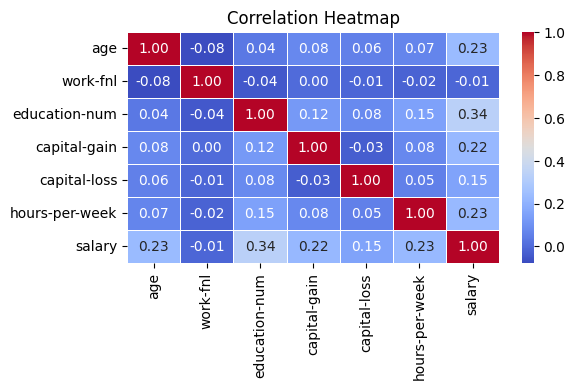

In [12]:
#6.Heatmap for the numerical data
corr_matrix = numeric_df.corr()
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

The plot says that there is no correlation between work-fnl and salary and that will be a noise for the models

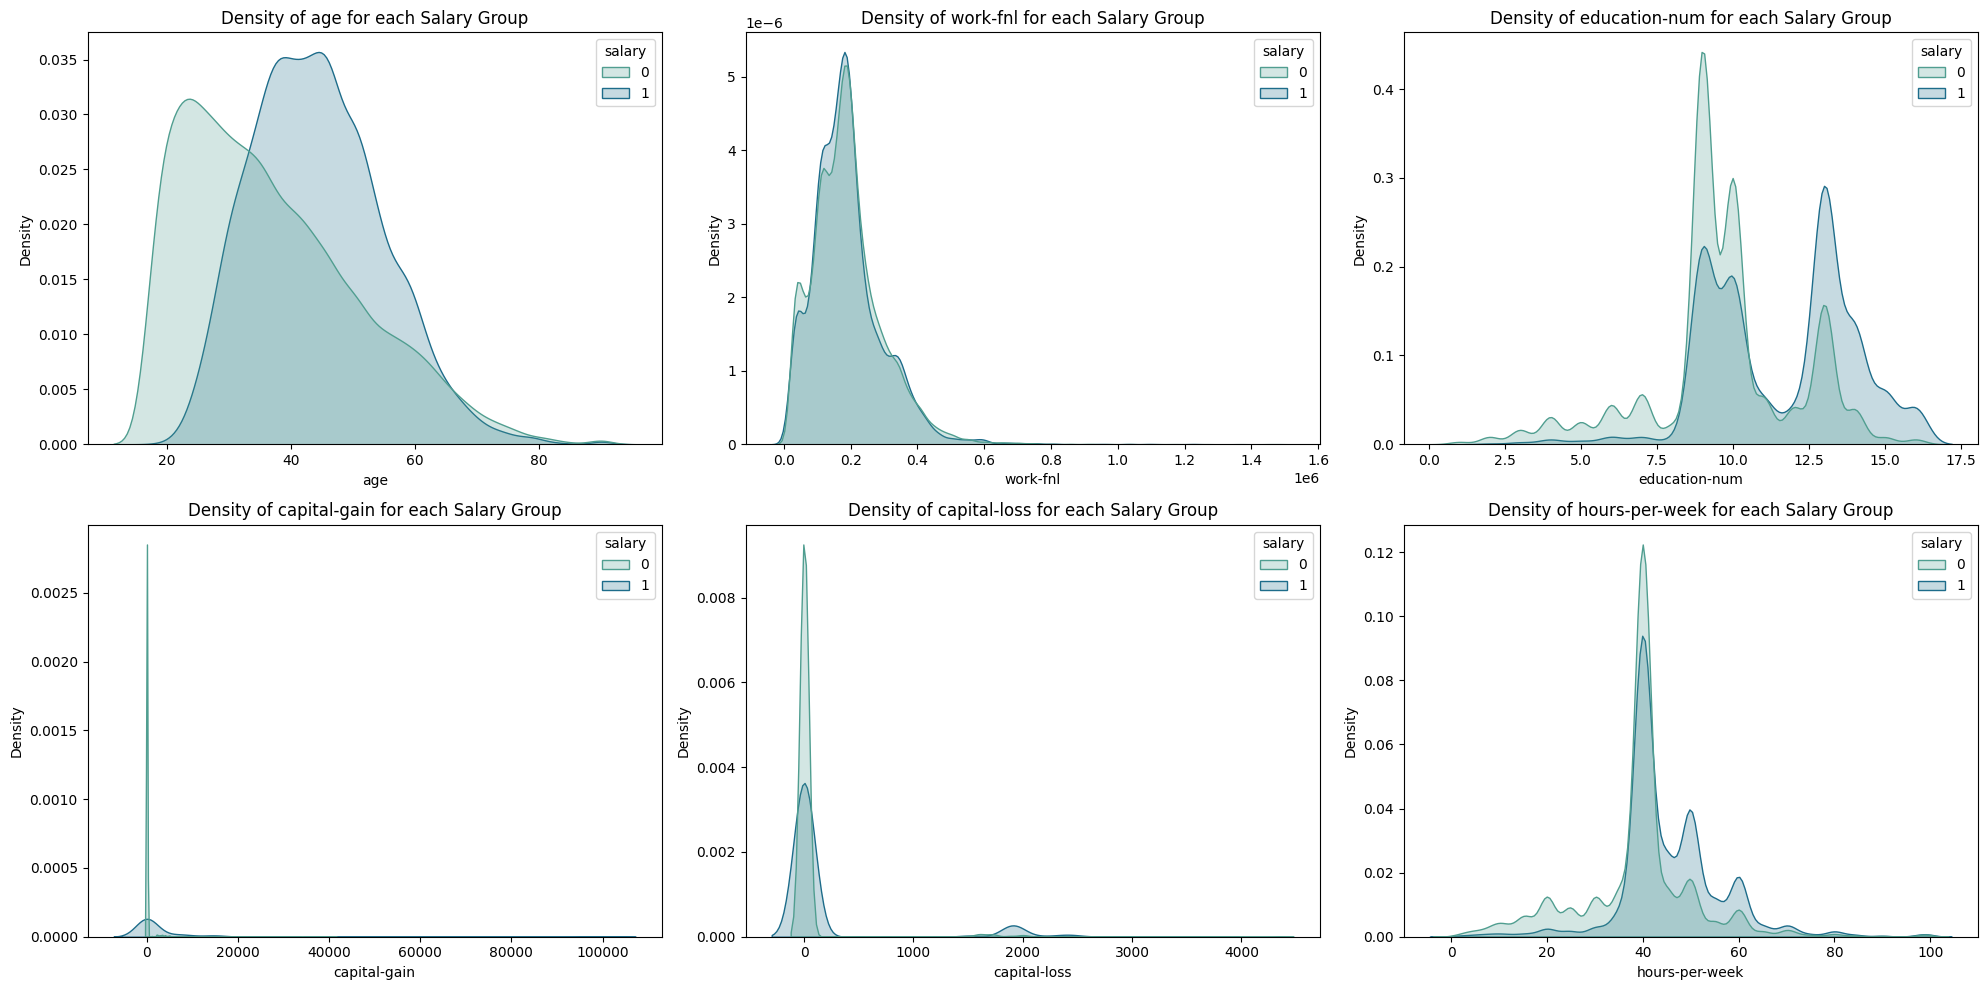

In [13]:
#7.kdplot for the numerical data 
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    if col == 'salary':
        continue
    sns.kdeplot(data=df, x=col, hue='salary', fill=True, common_norm=False, palette='crest', ax=axes[i])
    axes[i].set_title(f'Density of {col} for each Salary Group')
plt.tight_layout()
plt.show()

As the age become higher the chance for the salary to be more than 50k increase.

If the education level is low then the chance for the salary to be less than or equal to 50K is higher.

The capital-gain has a positive impact on the salary.

The capital-loss has a negative impact on the salary.

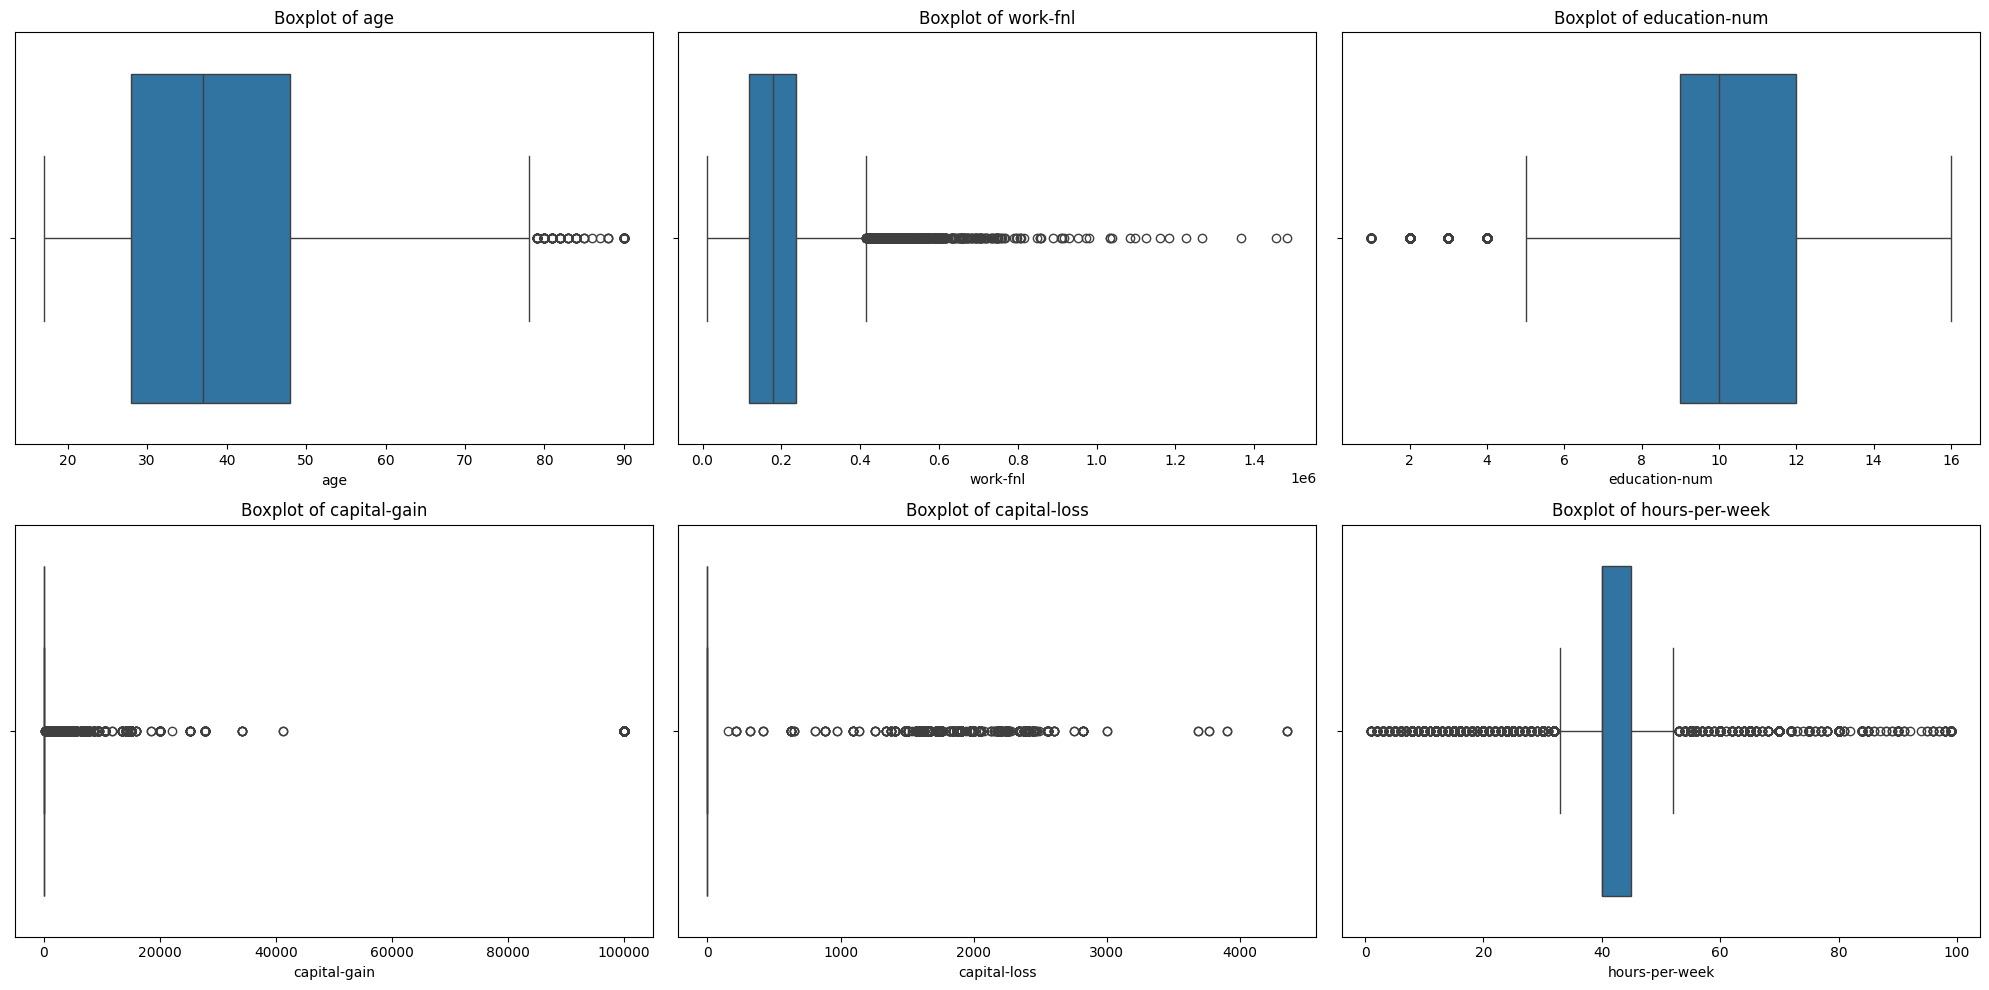

In [14]:
#8.Boxplot for the numerical data
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    if col == 'salary':
        continue
    sns.boxplot(data=df, x=col, fill=True, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

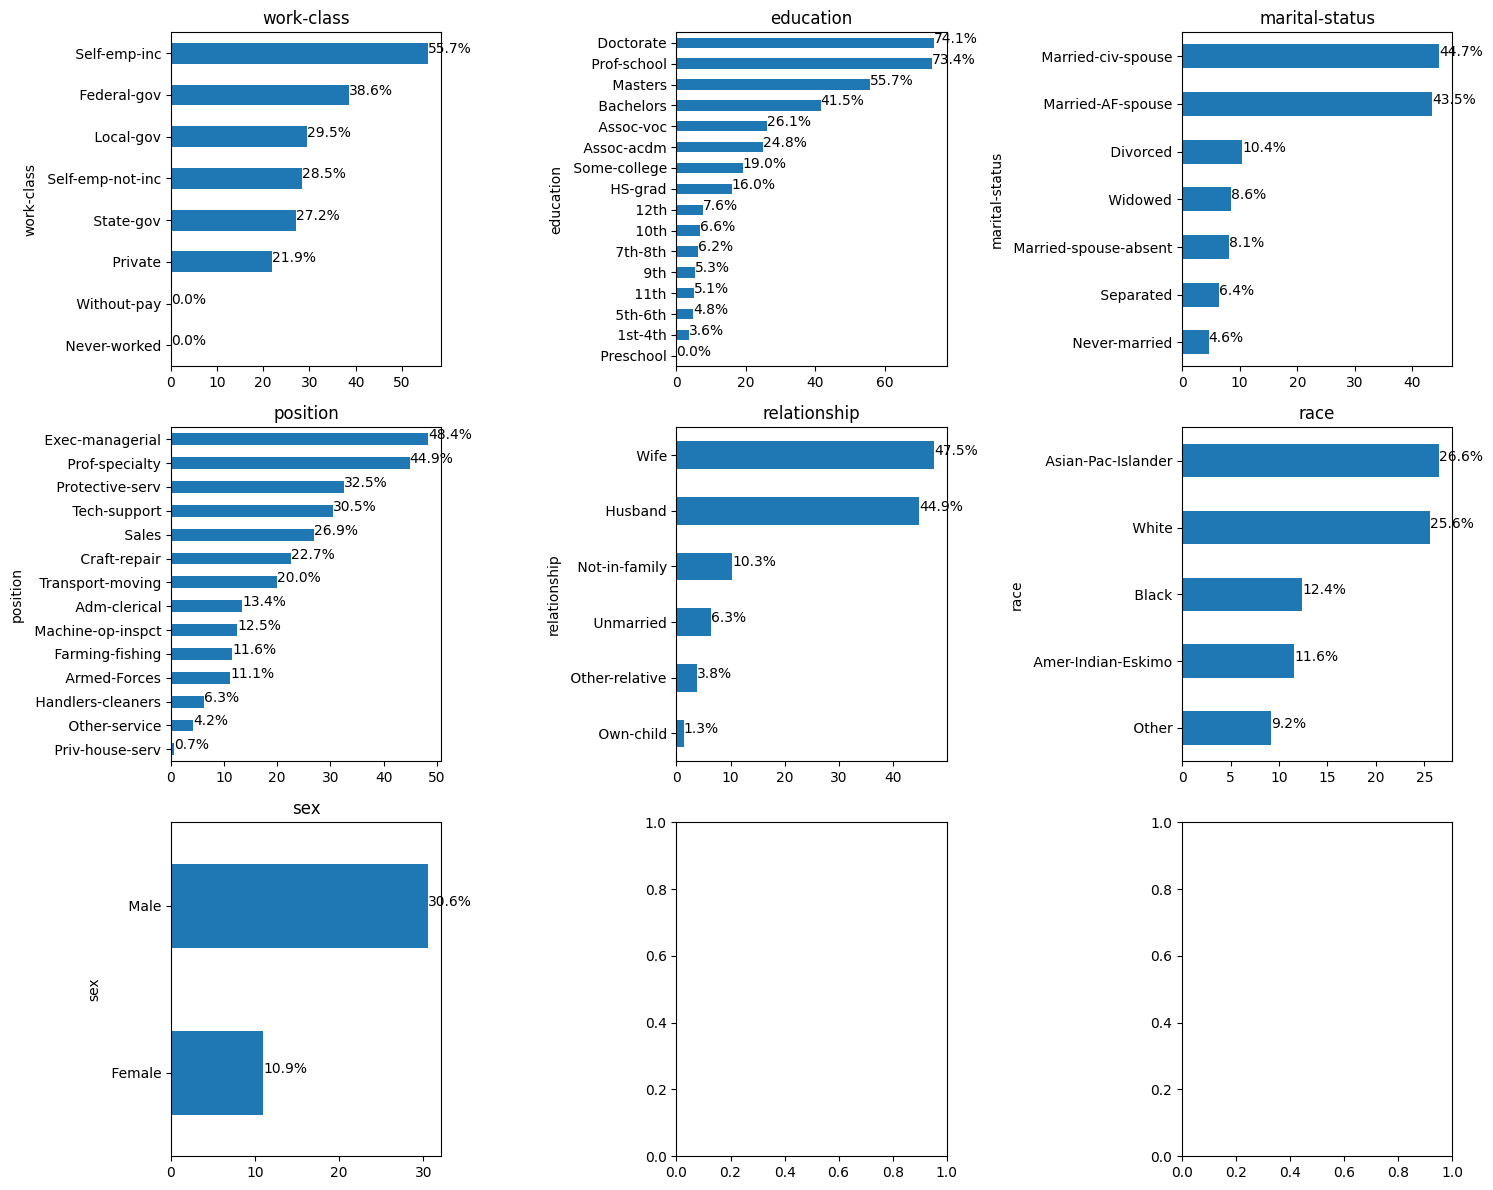

In [15]:
#9.Percentage of every category in the categorical data
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    feature_salary = pd.crosstab(df[col], df['salary'], normalize='index') * 100
    feature_salary = feature_salary.sort_values(by=1)
    plot = feature_salary[1].plot(kind='barh', ax=axes[i])
    for index, value in enumerate(feature_salary[1]):
        axes[i].text(value, index, f'{value:.1f}%')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

The plot explan the percentage of every category that would have a salary more than 50K


<a name="3"></a>
## Data Cleaning

<a name="3.1"></a>
### Remove nulls and unused columns

In [16]:
df.duplicated().sum()

np.int64(24)

In [17]:
#10.drop the duplicate rows
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
#11.remove the education as it is the sama a education-num
#.remove work-fnl as it will be noise for the models
df.drop(['work-fnl', 'education'], axis=1, inplace=True)

In [20]:
df.isnull().sum()

age                  0
work-class        1836
education-num        0
marital-status       0
position          1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     582
salary               0
dtype: int64

In [21]:
#12.remove rows that have null valus in work-class and position
df.dropna(subset=['work-class', 'position'], inplace=True)

In [22]:
df.isnull().sum()

age                 0
work-class          0
education-num       0
marital-status      0
position            0
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    555
salary              0
dtype: int64

In [23]:
#13.replace the null values in native-country with US
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

In [24]:
df.isnull().sum()

age               0
work-class        0
education-num     0
marital-status    0
position          0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

<a name="3.2"></a>
### Feature engineering

In [25]:
#14.
df['edu-workHours'] = df['education-num']**2 * df['hours-per-week']

In [26]:
df['bins'] = pd.qcut(df['edu-workHours'], q=5)
bin_result = df.groupby('bins')['salary'].mean()

print(bin_result)

bins
(9.999, 2560.0]      0.058281
(2560.0, 3240.0]     0.139161
(3240.0, 4225.0]     0.205042
(4225.0, 6760.0]     0.314841
(6760.0, 25344.0]    0.581578
Name: salary, dtype: float64


In [27]:
#15.
df['edu-age'] = df['education-num']**2 * df['age']

In [28]:
df['bins'] = pd.qcut(df['edu-age'], q=5)
bin_result = df.groupby('bins')['salary'].mean()

print(bin_result)

bins
(18.999, 2106.0]     0.032124
(2106.0, 3159.0]     0.123477
(3159.0, 4293.0]     0.220713
(4293.0, 6075.0]     0.318793
(6075.0, 20480.0]    0.557764
Name: salary, dtype: float64


In [29]:
#16.
df['workHours-age'] = df['hours-per-week'] * df['age']

In [30]:
df['bins'] = pd.qcut(df['workHours-age'], q=5)
bin_result = df.groupby('bins')['salary'].mean()

print(bin_result)

bins
(20.999, 1000.0]    0.031912
(1000.0, 1360.0]    0.141128
(1360.0, 1720.0]    0.271140
(1720.0, 2150.0]    0.383445
(2150.0, 8910.0]    0.436703
Name: salary, dtype: float64


In [31]:
df.drop('bins', axis=1, inplace=True)

<a name="3.3"></a>
### Encoding the categorical columns

In [32]:
#17.One-Hot Encoding 
df['sex'] = (df['sex'].str.contains('Male')).astype(int)
column_oneHot = ['marital-status', 'relationship', 'race']
df = pd.get_dummies(df, prefix=column_oneHot, columns=column_oneHot, dtype=int)

In [33]:
#18.separate the df to train and test again 
df_train = df.xs('train')
df_test = df.xs('test')

X_train = df_train.drop(columns='salary')
X_test = df_test.drop(columns='salary')

y_train = df_train['salary']
y_test = df_test['salary']

In [34]:
#19.Target encoding
column_target = ['work-class', 'position', 'native-country']
target_encoder = ce.TargetEncoder(cols=column_target, smoothing=70, verbose=1)
X_train = target_encoder.fit_transform(X_train, y_train)
X_test = target_encoder.transform(X_test)


<a name="3.4"></a>
### Data spliting 

In [35]:
#20.split the test data to validation data for model evaluation and test data for testing the models
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=0.5, random_state=433)

In [36]:
print(f'shape of X_train = {X_train.shape}')
print(f'shape of X_val = {X_val.shape}')
print(f'shape of X_test = {X_test.shape}')
print(f'shape of y_train = {y_train.shape}')
print(f'shape of y_test = {y_test.shape}')
print(f'shape of y_val = {y_val.shape}')

shape of X_train = (21498, 30)
shape of X_val = (4598, 30)
shape of X_test = (4598, 30)
shape of y_train = (21498,)
shape of y_test = (4598,)
shape of y_val = (4598,)


<a name="3.5"></a>
### Data normalization (z-score)

In [37]:
#21.Normalize the data for better performance on the trainning 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

<a name="4"></a>
## Dataframes Saving


In [39]:
# #22.
# X_train.to_csv('data/X_train.csv', index=False)
# y_train.to_csv('data/y_train.csv', index=False)

# X_val.to_csv('data/X_val.csv', index=False)
# y_val.to_csv('data/y_val.csv', index=False)

# X_test.to_csv('data/X_test.csv', index=False)
# y_test.to_csv('data/y_test.csv', index= False)

# joblib.dump(scaler, 'models/scaler.joblib')
# joblib.dump(target_encoder, 'models/target_encoder.joblib')